# DMD wrench model (error-state SRBD)

Train a linear DMD model on the SRBD **velocity error state** `e = [v_W, w_B] - [v_ref, w_ref]` with wrench inputs (6D). Identity lift, normalized features, and held-out trajectory evaluation.

## Setup
Update `data_path` to point to your recorded H5 (same format as other EDMD runners). Requires `cmd_base_lin_vel` and `cmd_base_ang_vel` logs.

In [1]:
from pathlib import Path
import importlib
import numpy as np
import matplotlib.pyplot as plt

import data_loader
importlib.reload(data_loader)
from data_loader import QuadrupedEDMDDataset
from edmd_runner import edmd_with_inputs


In [2]:
# Point to a recorded dataset
data_path = Path("../../datasets/go1/flat_terrain/experiment_body.h5")  # TODO: set to your log file

# Optional head trim to remove startup transients
CONTROL_FREQ = 50  # set to your control frequency in Hz
TRIM_HEAD_SEC = 1.0
RAW_DT = 0.002  # set to your raw dt
DOWNSAMPLE = int(round((1/RAW_DT)/CONTROL_FREQ))  # keep every k-th sample (1 = none)
EFFECTIVE_DT = RAW_DT * max(1, DOWNSAMPLE)

ds = QuadrupedEDMDDataset(
    file_path=str(data_path),
    input_mode="wrench",      # map GRFs + feet -> centroidal wrench
    downsample=DOWNSAMPLE,
    pos_zero_start=True,
    drop_nan=True,
    mask_inputs_by_contact=True,
    use_body_ang_vel=True,    # required for body angular velocity in error state
    trim_head_sec=TRIM_HEAD_SEC,
    sample_dt=EFFECTIVE_DT,
)
ds = ds.build()

x_ref0 = getattr(ds, "x_ref0", None)
x_ref1 = getattr(ds, "x_ref1", None)
if x_ref0 is None or x_ref1 is None:
    raise ValueError("x_ref0/x_ref1 missing: ensure you're importing the updated data_loader.py (restart kernel if needed).")

X0_raw, X1_raw, U0 = ds.X0, ds.X1, ds.U0
bounds_trim = ds.episode_bounds

traj_ids_all = np.zeros(X0_raw.shape[0], dtype=int)
for i, (s, e) in enumerate(bounds_trim):
    traj_ids_all[s:e] = i
traj_i50ds_all = traj_ids_all

# Build error-state: e = [v_W, w_B] - [v_ref, w_ref]
def extract_xd(X):
    v_w = X[:, 6:9]
    w_b = X[:, 9:12]
    return np.concatenate([v_w, w_b], axis=1)

X0_d = extract_xd(X0_raw)
X1_d = extract_xd(X1_raw)
X0 = X0_d - x_ref0
X1 = X1_d - x_ref1

print(f"X0 (error) shape {X0.shape}, U0 {U0.shape}, trim_head_sec={TRIM_HEAD_SEC}, episodes={len(bounds_trim)}")


X0 (error) shape (44900, 6), U0 (44900, 6), trim_head_sec=1.0, episodes=100


## Normalize error state and inputs

In [3]:
eps = 1e-8
NORMALIZE = False

if NORMALIZE:
    mu_x = X0.mean(axis=0)
    std_x = X0.std(axis=0) + eps
    mu_u = U0.mean(axis=0)
    std_u = U0.std(axis=0) + eps

    def norm_x(X):
        return (X - mu_x) / std_x

    def denorm_x(Xn):
        return Xn * std_x + mu_x

    def norm_u(U):
        return (U - mu_u) / std_u
else:
    mu_x = np.zeros(X0.shape[1])
    std_x = np.ones(X0.shape[1])
    mu_u = np.zeros(U0.shape[1])
    std_u = np.ones(U0.shape[1])

    def norm_x(X):
        return X

    def denorm_x(Xn):
        return Xn

    def norm_u(U):
        return U

X0_n, X1_n, U0_n = norm_x(X0), norm_x(X1), norm_u(U0)


## Train DMD (identity lift) on error state

In [4]:
lift_fn = lambda x: np.asarray(x, float).reshape(-1)

# Unique trajectory IDs (after trimming)
unique_ids = np.arange(len(bounds_trim))
n_traj = len(unique_ids)
n_val = max(1, int(0.1 * n_traj))
n_test = max(1, int(0.2 * n_traj))
perm = np.random.permutation(unique_ids)
val_ids = perm[:n_val]
test_ids = perm[n_val : n_val + n_test]
train_ids = perm[n_val + n_test :]
print(f"Train traj: {train_ids}, Val traj: {val_ids}, Test traj: {test_ids}")

def mask_from_bounds(id_list):
    m = np.zeros_like(traj_ids_all, dtype=bool)
    for tid in id_list:
        s, e = bounds_trim[int(tid)]
        m[s:e] = True
    return m

train_mask = mask_from_bounds(train_ids)
val_mask = mask_from_bounds(val_ids)
test_mask = mask_from_bounds(test_ids)

def fit_dmd(X0n, X1n, U0n, l2):
    return edmd_with_inputs(X0n, X1n, U0n, lift_fn=lift_fn, l2_reg=l2)

def rollout_linear_norm(A, B, x0n, U_seq_n):
    x = x0n.copy()
    traj = [x]
    for u in U_seq_n:
        x = A @ x + B @ u
        traj.append(x.copy())
    return np.vstack(traj)

def multistep_rmse(A, B, id_list, H=50):
    rmses = []
    for tid in id_list:
        s, e = bounds_trim[int(tid)]
        if (e - s) < H + 1:
            continue
        for j in range(s, e - H - 1):
            x0n = X0_n[j]
            U_seq_n = U0_n[j : j + H]
            gt = X0[j : j + H + 1]
            pred_n = rollout_linear_norm(A, B, x0n, U_seq_n)
            pred = denorm_x(pred_n)
            err = pred[1:] - gt[1:]
            rmses.append(np.sqrt(np.mean(err**2, axis=0)))
    if not rmses:
        return np.inf
    rmses = np.vstack(rmses)
    return float(np.sqrt(np.mean(rmses**2)))

# Fixed ridge for simplicity
l2_fixed = 1e-6
A_best, B_best = fit_dmd(X0_n[train_mask], X1_n[train_mask], U0_n[train_mask], l2_fixed)
val_rmse = multistep_rmse(A_best, B_best, val_ids, H=50)
vals = np.linalg.eigvals(A_best)
rho = np.max(np.abs(vals))
print(f"val_rmse={val_rmse:.4f}, spectral radius {rho:.4f}, l2={l2_fixed}")


Train traj: [29 21 90 85 97 30 23  7  9 33 64 67 83 46 54 99 12 47 16 61 69 37 19 63
 32 78 44 31 51 88 48 55 72 74  1 75 27 41 35 86 52 43 98 80 38 53  0 45
 11 56 96 17 24 66 14 81 18 49  6 40 57 20 62 92  2  5 13 39 10 59], Val traj: [50 28  4 94 79 68  8 26 95 77], Test traj: [71 42 65 73 36 82  3 93 84 76 58 91 34 70 89 22 25 60 87 15]
val_rmse=0.0397, spectral radius 0.9069, l2=1e-06


## Test evaluation (per trajectory) and RMSE stats (de-normalized, error state)

traj 71 rmse: [0.02695882 0.03701416 0.0231754  0.05793732 0.06757979 0.03092415]
traj 42 rmse: [0.02065403 0.04260805 0.02237058 0.06217107 0.05383815 0.03537176]
traj 65 rmse: [0.01240086 0.01255229 0.02247837 0.05018289 0.05063706 0.01651613]
traj 73 rmse: [0.03574452 0.01444977 0.02264252 0.0519085  0.05357365 0.02333196]
traj 36 rmse: [0.02259429 0.02802729 0.02357177 0.0497883  0.05609683 0.04376775]
traj 82 rmse: [0.02135067 0.02893084 0.02302318 0.05569537 0.0557     0.01690508]
traj 3 rmse: [0.02359917 0.02624892 0.0238819  0.05209114 0.04980592 0.01571759]
traj 93 rmse: [0.01349021 0.01962783 0.02265415 0.05176963 0.04801502 0.02778254]
traj 84 rmse: [0.03402905 0.01677919 0.02315815 0.05254854 0.06788624 0.04495846]
traj 76 rmse: [0.02554259 0.0115627  0.02273748 0.05749153 0.04439887 0.03239246]
traj 58 rmse: [0.03284045 0.05174908 0.02520825 0.0664085  0.0749666  0.03031659]
traj 91 rmse: [0.03055619 0.03792505 0.02356004 0.06107101 0.06676046 0.03256804]
traj 34 rmse: [0.

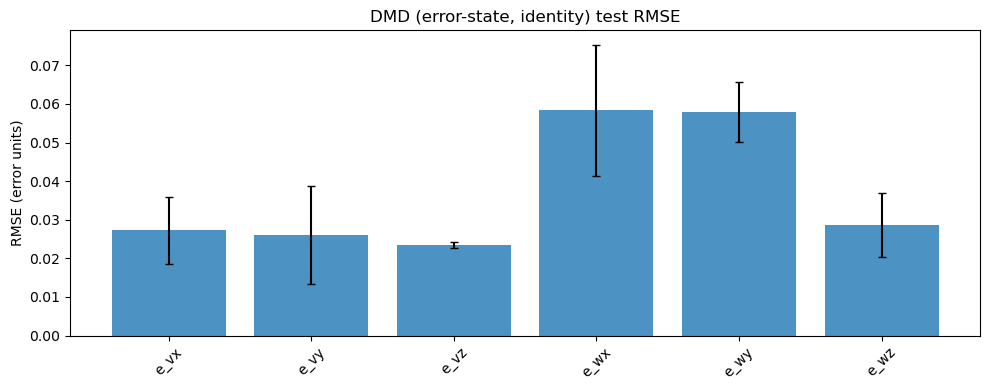

In [5]:
state_labels = [
    "e_vx", "e_vy", "e_vz",
    "e_wx", "e_wy", "e_wz",
]

def eval_dmd_on_traj(A, B, mask):
    x0n = X0_n[mask][0]
    U_seq_n = U0_n[mask]
    gt_next = X1[mask]
    pred_n = rollout_linear_norm(A, B, x0n, U_seq_n)
    pred = denorm_x(pred_n)
    err = pred[1:] - gt_next
    rmse = np.sqrt(np.mean(err**2, axis=0))
    return rmse

rmse_list = []
for tid in test_ids:
    mask = mask_from_bounds([tid])
    rmse = eval_dmd_on_traj(A_best, B_best, mask)
    rmse_list.append(rmse)
    print(f"traj {tid} rmse: {rmse}")

rmse_arr = np.vstack(rmse_list)
rmse_mean = rmse_arr.mean(axis=0)
rmse_std = rmse_arr.std(axis=0)
print("Mean RMSE:", rmse_mean)
print("Std RMSE:", rmse_std)

# Plot
x_pos = np.arange(len(state_labels))
plt.figure(figsize=(10,4))
plt.bar(x_pos, rmse_mean, yerr=rmse_std, alpha=0.8, capsize=3)
plt.xticks(x_pos, state_labels, rotation=45)
plt.ylabel("RMSE (error units)")
plt.title("DMD (error-state, identity) test RMSE")
plt.tight_layout()
plt.show()


## Quick rollout check (random window)

Per-state RMSE: [0.02087648 0.02869534 0.02121297 0.04635945 0.06368871 0.0144086 ]
Overall RMSE: 0.03679288414084475


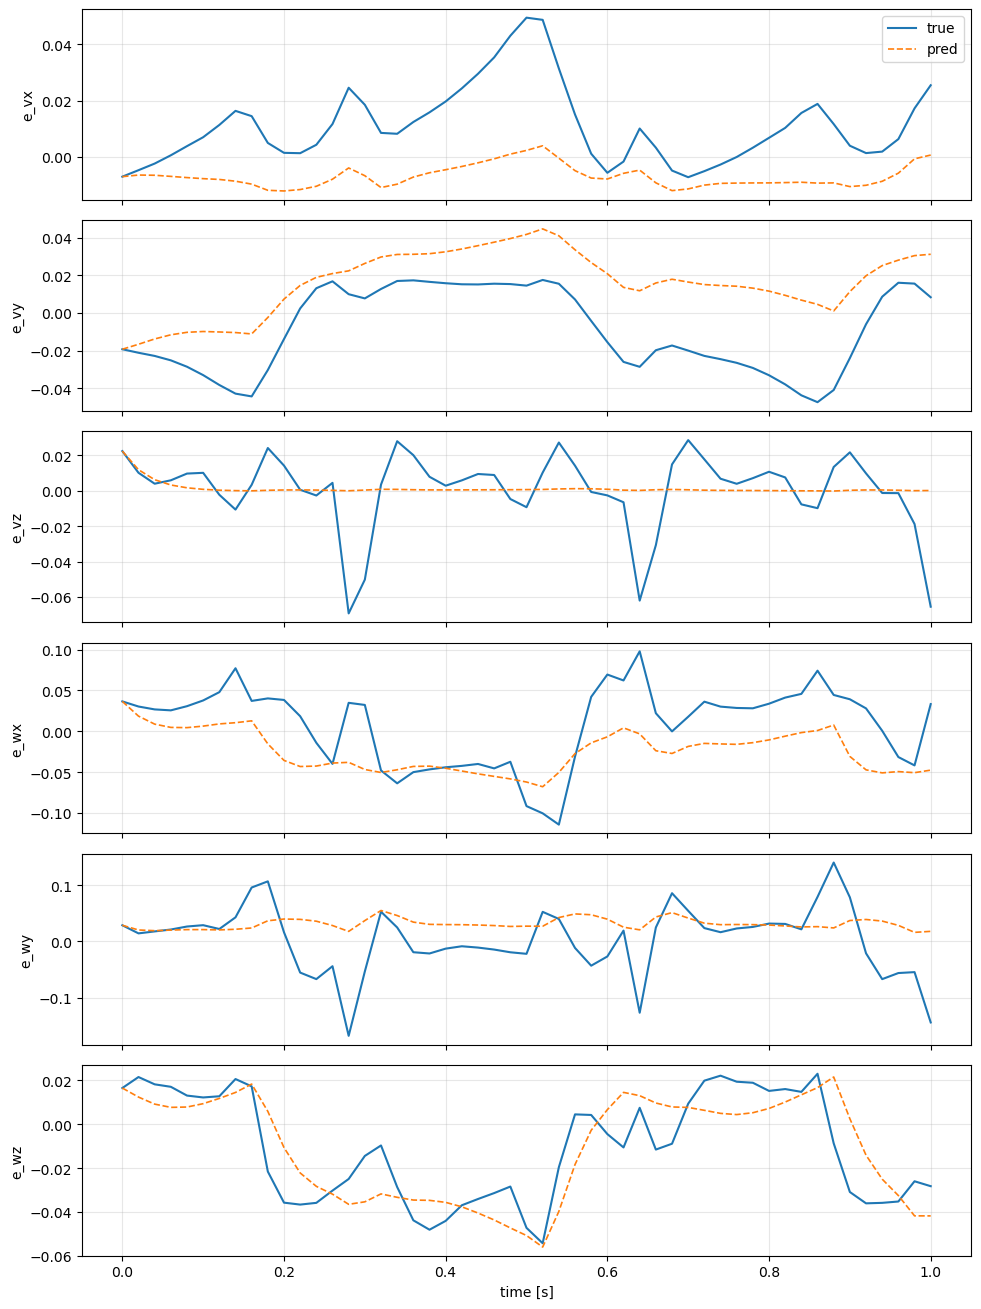

In [6]:
H = 50
idx = np.random.randint(0, X0.shape[0] - H - 1)
x0n = X0_n[idx]
U_seq_n = U0_n[idx : idx + H]
gt = X0[idx : idx + H + 1]
pred_n = rollout_linear_norm(A_best, B_best, x0n, U_seq_n)
pred = denorm_x(pred_n)
err = pred - gt
rmse = np.sqrt(np.mean(err**2, axis=0))
print("Per-state RMSE:", rmse)
print("Overall RMSE:", float(np.sqrt(np.mean(rmse**2))))

# Plot per-state time series (true vs pred)
try:
    dt = EFFECTIVE_DT
except NameError:
    dt = 1.0

t = np.arange(pred.shape[0]) * dt
n_states = pred.shape[1]
fig, axes = plt.subplots(n_states, 1, figsize=(10, 2.2 * n_states), sharex=True)
if n_states == 1:
    axes = [axes]
for i in range(n_states):
    axes[i].plot(t, gt[:, i], label="true", linewidth=1.5)
    axes[i].plot(t, pred[:, i], label="pred", linewidth=1.2, linestyle="--")
    label = state_labels[i] if i < len(state_labels) else f"state_{i}"
    axes[i].set_ylabel(label)
    axes[i].grid(True, alpha=0.3)
axes[-1].set_xlabel("time [s]")
axes[0].legend(loc="best")
plt.tight_layout()
plt.show()


## Save model

In [7]:
out_dir = Path("saved_models_koopman")
out_dir.mkdir(exist_ok=True, parents=True)
out_path = out_dir / "dmd_wrench_errorstate.npz"
meta = {
    "method": "dmd_error_state",
    "input_mode": "wrench",
    "normalize": NORMALIZE,
    "mu_x": mu_x,
    "std_x": std_x,
    "mu_u": mu_u,
    "std_u": std_u,
    "state_layout": "[e_vW(3), e_wB(3)]",
    "x_ref_layout": "[cmd_base_lin_vel(3), cmd_base_ang_vel(3)]",
    "lift": "identity",
    "ridge": l2_fixed,
    "use_body_ang_vel": True,
    "error_state": True,
}
np.savez(out_path, A=A_best, B=B_best, meta=meta)
print(f"Saved to {out_path}")


Saved to saved_models_koopman/dmd_wrench_errorstate.npz
